<a href="https://colab.research.google.com/github/Taka-0226/care-certification-analysis/blob/main/%E8%A6%81%E4%BB%8B%E8%AD%B7%E8%AA%8D%E5%AE%9A%E7%8E%87%E3%81%AE%E4%BA%88%E6%B8%AC%E3%83%A2%E3%83%87%E3%83%AB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

要介護認定率を予測するモデルを作成する。説明変数として、75歳以上高齢者人口の割合、介護施設密度(10万人当たり)、一人当たり所得、人口密度を使う。

##65歳以上の要介護認定率を求める

In [ ]:
#第1号被保険者数の確認

import pandas as pd

df_insured = pd.read_excel("第1号被保険者数.xlsx", header = 3)

df_insured.head(10)

,都道府県,前月末現在,当月中増,当月中減,当月末現在,Unnamed: 5,Unnamed: 6,Unnamed: 7
0,NaN,NaN,NaN,NaN,NaN,６５歳以上_x000D_\n７５歳未満,７５歳以上_x000D_\n８５歳未満,８５歳以上
1,全国計,35880601.0,148541.0,148078.0,35881064.0,15919665,13421643,6539756
2,北海道,1666353.0,5970.0,7007.0,1665316.0,757479,596811,311026
3,青森県,419557.0,1532.0,1921.0,419168.0,196827,143950,78391
4,岩手県,407327.0,1476.0,1778.0,407025.0,185319,137787,83919
5,宮城県,655576.0,2788.0,2641.0,655723.0,312631,223471,119621
6,秋田県,357329.0,1266.0,1556.0,357039.0,162019,118825,76195
7,山形県,358995.0,1304.0,1632.0,358667.0,165019,118494,75154
8,福島県,589145.0,2526.0,2389.0,589282.0,282864,194112,112306
9,茨城県,860644.0,3693.0,3589.0,860748.0,401178,318996,140574


In [ ]:
df_insured = df_insured[["都道府県", "当月末現在"]]

In [ ]:
df_insured = df_insured[df_insured["都道府県"] != "全国計"]

In [ ]:
df_insured = df_insured.dropna()

In [ ]:
df_insured = df_insured.rename(columns = {"当月末現在": "第1号被保険者数"})

In [ ]:
#介護認定を受けている人数の確認

df_certified = pd.read_excel("第2－1表要介護（要支援）認定者数（2023）.xlsx", skiprows = 3)

df_certified.head(10)

,都道府県,総数,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,都道府県.1,...,Unnamed: 71,都道府県.8,（再掲）第２号被保険者,Unnamed: 74,Unnamed: 75,Unnamed: 76,Unnamed: 77,Unnamed: 78,Unnamed: 79,Unnamed: 80
0,NaN,要支援１,要支援２,要介護１,要介護２,要介護３,要介護４,要介護５,合計,NaN,...,計,NaN,要支援１,要支援２,要介護１,要介護２,要介護３,要介護４,要介護５,計
1,全国計,1013903,990948,1464979,1187068,928811,897485,597461,7080655,全国計,...,1999433,全国計,12487,20066,21175,27026,18164,16363,16329,131610
2,北海道,66093,51819,81833,55608,37169,36344,25517,354383,北海道,...,98085,北海道,655,923,1162,1131,604,567,608,5650
3,青森県,6860,7741,16200,15725,10989,11399,8330,77244,青森県,...,22275,青森県,91,157,239,372,205,203,219,1486
4,岩手県,10033,10029,16098,15064,11148,11200,7509,81081,岩手県,...,26091,岩手県,162,236,243,333,193,196,163,1526
5,宮城県,22399,16695,25870,20055,15478,16415,10136,127048,宮城県,...,38174,宮城県,307,360,367,468,321,299,297,2419
6,秋田県,8290,8357,15923,13174,10650,10022,6672,73088,秋田県,...,24082,秋田県,85,145,242,273,162,156,118,1181
7,山形県,6125,7308,13271,12497,9565,9108,6139,64013,山形県,...,23274,山形県,104,172,157,213,114,130,133,1023
8,福島県,14154,14910,23001,20612,16623,16421,10476,116197,福島県,...,37052,福島県,212,352,407,491,331,372,277,2442
9,茨城県,16161,17219,32443,25336,20480,19005,11692,142336,茨城県,...,40716,茨城県,227,355,598,691,483,374,366,3094


In [ ]:
#介護認定者総数と第２号認定者数を抽出する。

df_certified = df_certified[["都道府県", "Unnamed: 8", "Unnamed: 80"]]

In [ ]:
df_certified = df_certified.rename(columns = {"Unnamed: 8":"認定者数", "Unnamed: 80":"第２号認定者数"})

In [ ]:
df_certified = df_certified.dropna()

In [ ]:
df_certified = df_certified[df_certified["都道府県"] != "全国計"]

In [ ]:
df_certified = df_certified.reset_index(drop = True)

In [ ]:
#認定者総数から第２号認定者数を除き、第1号被保険者の認定率を求める

df_certified["第１号認定者数"] = df_certified["認定者数"] - df_certified["第２号認定者数"]

In [ ]:
df_certified = df_certified[["都道府県", "第１号認定者数"]]

In [ ]:
#データ結合
df_merged = pd.merge(
    df_insured,
    df_certified,
    on = "都道府県",
    how = "inner"
)

df_merged.head()

,都道府県,第1号被保険者数,第１号認定者数
0,北海道,1665316.0,348733
1,青森県,419168.0,75758
2,岩手県,407025.0,79555
3,宮城県,655723.0,124629
4,秋田県,357039.0,71907


In [ ]:
#認定率を計算

df_merged["認定率(%)"] = (df_merged["第１号認定者数"] / df_merged["第1号被保険者数"]) * 100

In [ ]:
#認定率で並び替え

df_rank = df_merged.sort_values("認定率(%)", ascending = False)

In [ ]:
#merge後にindexをリセット

df_rank = df_rank.reset_index(drop = True)

df_rank.head()

,都道府県,第1号被保険者数,第１号認定者数,認定率(%)
0,大阪府,2361724.0,558491,23.647598
1,京都府,735130.0,168203,22.880715
2,和歌山県,306615.0,67460,22.001533
3,岡山県,566907.0,120591,21.271743
4,兵庫県,1580925.0,335342,21.211759


In [ ]:
#colab環境用

!pip install japanize-matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 21.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for japanize-matplotlib: filename=japanize_matplotlib-1.1.3-py3-none-any.whl size=4120257 sha256=8fa2fc28df8f3da0624b1ce131262b5b242afc73f2dcc49cb0839422462492fd
  Stored in directory: /root/.cache/pip/wheels/c1/f7/9b/418f19a7b9340fc16e071e89efc379aca68d40238b258df53d
Successfully built japanize-matplotlib


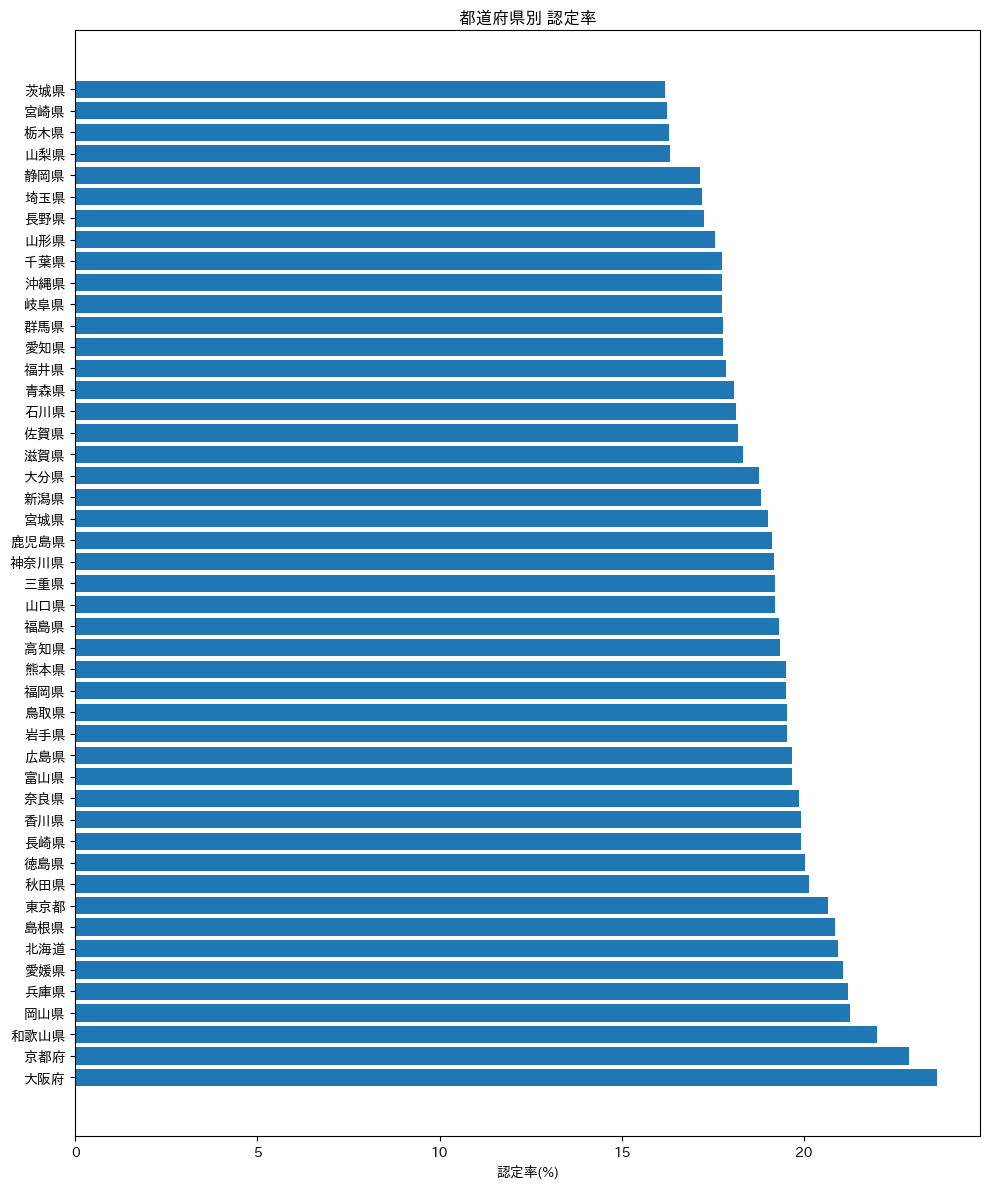

In [ ]:
#可視化
import matplotlib.pyplot as plt
import japanize_matplotlib

plt.figure(figsize=(10, 12))

plt.barh(
    df_rank["都道府県"],
    df_rank["認定率(%)"]
)

plt.title("都道府県別 認定率")

plt.xlabel("認定率(%)")

plt.tight_layout()

plt.show()

##75歳以上高齢割合を求める

In [ ]:
df_pop_total = pd.read_excel("人口統計階級別(2023).xlsx", header = 6)

df_pop_total.head(10)

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,時間軸コード,時点,人口区分,...,40～44歳,45～49歳,50～54歳,55～59歳,60～64歳,65～69歳,70～74歳,75～79歳,80～84歳,85歳以上
0,1000,,1,1,NaN,NaN,NaN,2023001010,2023年10月1日現在,総人口,...,7765,9115,9650,8279,7507,7332,8817,7474,5895,6708
1,1000,,1,1,NaN,NaN,NaN,2023001010,2023年10月1日現在,総人口,...,306,368,379,341,336,342,425,333,262,320
2,1000,,1,1,NaN,NaN,NaN,2023001010,2023年10月1日現在,総人口,...,70,82,86,82,86,91,105,80,62,79
3,1000,,1,1,NaN,NaN,NaN,2023001010,2023年10月1日現在,総人口,...,69,80,81,77,82,87,99,74,62,84
4,1000,,1,1,NaN,NaN,NaN,2023001010,2023年10月1日現在,総人口,...,149,167,165,143,142,148,170,125,98,122
5,1000,,1,1,NaN,NaN,NaN,2023001010,2023年10月1日現在,総人口,...,52,62,61,59,68,75,87,64,53,76
6,1000,,1,1,NaN,NaN,NaN,2023001010,2023年10月1日現在,総人口,...,61,69,68,65,71,77,90,65,53,77
7,1000,,1,1,NaN,NaN,NaN,2023001010,2023年10月1日現在,総人口,...,106,122,122,116,126,134,149,106,85,112
8,1000,,1,1,NaN,NaN,NaN,2023001010,2023年10月1日現在,総人口,...,176,206,217,184,173,185,220,179,137,144
9,1000,,1,1,NaN,NaN,NaN,2023001010,2023年10月1日現在,総人口,...,121,141,145,124,119,127,149,116,86,95


In [ ]:
df_pop = df_pop_total.rename(columns = {
    "地域": "都道府県",
    "総数": "総人口"
    })

In [ ]:
df_pop["人口区分"].unique()

array(['総人口', '日本人人口'], dtype=object)

In [ ]:
df_pop["性別"].unique()

array(['男女計', '男', '女'], dtype=object)

In [ ]:
df_pop = df_pop[
    (df_pop["人口区分"] == "総人口") &
    (df_pop["性別"] == "男女計")
]

In [ ]:
#総人口における75歳以上人口の割合を求める

df_pop["75歳以上人口(千人)"] = df_pop["75～79歳"] + df_pop["80～84歳"] + df_pop["85歳以上"]

df_pop["75歳以上割合"] = (df_pop["75歳以上人口(千人)"] / df_pop["総人口"]) * 100

df_pop.head()

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,時間軸コード,時点,人口区分,...,50～54歳,55～59歳,60～64歳,65～69歳,70～74歳,75～79歳,80～84歳,85歳以上,75歳以上人口(千人),75歳以上割合
0,1000,,1,1,NaN,NaN,NaN,2023001010,2023年10月1日現在,総人口,...,9650,8279,7507,7332,8817,7474,5895,6708,20077,16.145297
1,1000,,1,1,NaN,NaN,NaN,2023001010,2023年10月1日現在,総人口,...,379,341,336,342,425,333,262,320,915,17.969364
2,1000,,1,1,NaN,NaN,NaN,2023001010,2023年10月1日現在,総人口,...,86,82,86,91,105,80,62,79,221,18.665541
3,1000,,1,1,NaN,NaN,NaN,2023001010,2023年10月1日現在,総人口,...,81,77,82,87,99,74,62,84,220,18.916595
4,1000,,1,1,NaN,NaN,NaN,2023001010,2023年10月1日現在,総人口,...,165,143,142,148,170,125,98,122,345,15.238516


In [ ]:
df_pop = df_pop[["都道府県", "75歳以上人口(千人)", "75歳以上割合"]]

df_pop.head(10)

,都道府県,75歳以上人口(千人),75歳以上割合
0,全国,20077,16.145297
1,北海道,915,17.969364
2,青森県,221,18.665541
3,岩手県,220,18.916595
4,宮城県,345,15.238516
5,秋田県,193,21.115974
6,山形県,195,19.005848
7,福島県,303,17.147708
8,茨城県,460,16.283186
9,栃木県,297,15.656299


In [ ]:
df_pop = df_pop[df_pop["都道府県"] != "全国"]

df_pop.head()

,都道府県,75歳以上人口(千人),75歳以上割合
1,北海道,915,17.969364
2,青森県,221,18.665541
3,岩手県,220,18.916595
4,宮城県,345,15.238516
5,秋田県,193,21.115974


In [ ]:
#unigueで重複を除いた値を確認し10個表示
#全角スペースが4つついている

print(df_pop["都道府県"].unique()[:10])
print(df_merged["都道府県"].unique()[:10])

['北海道\u3000\u3000\u3000\u3000' '青森県\u3000\u3000\u3000\u3000'
 '岩手県\u3000\u3000\u3000\u3000' '宮城県\u3000\u3000\u3000\u3000'
 '秋田県\u3000\u3000\u3000\u3000' '山形県\u3000\u3000\u3000\u3000'
 '福島県\u3000\u3000\u3000\u3000' '茨城県\u3000\u3000\u3000\u3000'
 '栃木県\u3000\u3000\u3000\u3000' '群馬県\u3000\u3000\u3000\u3000']
['北海道' '青森県' '岩手県' '宮城県' '秋田県' '山形県' '福島県' '茨城県' '栃木県' '群馬県']


In [ ]:
#スペースの削除

df_pop["都道府県"] = df_pop["都道府県"].str.strip()
df_merged["都道府県"] = df_merged["都道府県"].str.strip()

In [ ]:
#mergedへ結合

df_merged = pd.merge(
    df_merged,
    df_pop,
    on="都道府県",
    how="inner"
)

df_merged.head()

,都道府県,第1号被保険者数,第１号認定者数,認定率(%),75歳以上人口(千人),75歳以上割合
0,北海道,1665316.0,348733,20.940951,915,17.969364
1,青森県,419168.0,75758,18.073422,221,18.665541
2,岩手県,407025.0,79555,19.545482,220,18.916595
3,宮城県,655723.0,124629,19.006349,345,15.238516
4,秋田県,357039.0,71907,20.139817,193,21.115974


##介護施設数の割合計算

In [ ]:
df_facility = pd.read_csv("介護施設数.csv",  encoding="cp932", skiprows=7)

df_facility.head(10)

,Unnamed: 0,施設・事業所,施設・事業所.1,施設・事業所.2,施設・事業所.3,施設・事業所.4,施設・事業所.5,施設・事業所.6,施設・事業所.7,施設・事業所.8,...,施設・事業所.206,施設・事業所.207,施設・事業所.208,施設・事業所.209,施設・事業所.210,施設・事業所.211,施設・事業所.212,施設・事業所.213,施設・事業所.214,施設・事業所.215
0,全国,78079,13227,64852,284,15,269,185,11,174,...,1,128,-,128,18460,3,18457,6425,2,6423
1,国,10,9,1,-,-,-,-,-,-,...,-,-,-,-,-,-,-,-,-,-
2,北海道,3997,676,3321,11,-,11,9,-,9,...,-,1,-,1,1147,-,1147,484,1,483
3,青森県,1065,83,982,3,-,3,3,-,3,...,-,-,-,-,483,-,483,-,-,-
4,岩手県,983,135,848,4,-,4,2,-,2,...,-,-,-,-,282,-,282,30,-,30
5,宮城県,1634,318,1316,2,-,2,2,-,2,...,-,2,-,2,245,-,245,126,-,126
6,秋田県,652,114,538,3,-,3,2,-,2,...,-,-,-,-,116,-,116,73,-,73
7,山形県,774,159,615,4,-,4,3,-,3,...,-,-,-,-,244,-,244,7,-,7
8,福島県,942,190,752,10,1,9,6,-,6,...,1,-,-,-,177,-,177,111,-,111
9,茨城県,1429,174,1255,5,-,5,5,-,5,...,-,5,-,5,218,-,218,208,-,208


In [ ]:
df_facility = df_facility[~df_facility["Unnamed: 0"].isin(["全国", "国"])]

df_facility.head()

,Unnamed: 0,施設・事業所,施設・事業所.1,施設・事業所.2,施設・事業所.3,施設・事業所.4,施設・事業所.5,施設・事業所.6,施設・事業所.7,施設・事業所.8,...,施設・事業所.206,施設・事業所.207,施設・事業所.208,施設・事業所.209,施設・事業所.210,施設・事業所.211,施設・事業所.212,施設・事業所.213,施設・事業所.214,施設・事業所.215
2,北海道,3997,676,3321,11,-,11,9,-,9,...,-,1,-,1,1147,-,1147,484,1,483
3,青森県,1065,83,982,3,-,3,3,-,3,...,-,-,-,-,483,-,483,-,-,-
4,岩手県,983,135,848,4,-,4,2,-,2,...,-,-,-,-,282,-,282,30,-,30
5,宮城県,1634,318,1316,2,-,2,2,-,2,...,-,2,-,2,245,-,245,126,-,126
6,秋田県,652,114,538,3,-,3,2,-,2,...,-,-,-,-,116,-,116,73,-,73


In [ ]:
#都道府県と介護施設数を抽出

df_facility = df_facility.rename(columns = {"Unnamed: 0": "都道府県", "施設・事業所": "介護施設数"})

df_facility = df_facility[["都道府県", "介護施設数"]]

df_facility.head()

,都道府県,介護施設数
2,北海道,3997
3,青森県,1065
4,岩手県,983
5,宮城県,1634
6,秋田県,652


In [ ]:
df_facility = df_facility.reset_index(drop = True)

In [ ]:
df_pop = df_pop.reset_index(drop = True)

In [ ]:
#介護施設数÷75歳以上人口によって、高齢者一人当たりどれだけの施設があるかを求める

df_facility["介護施設密度"] = df_facility["介護施設数"] / (df_pop["75歳以上人口(千人)"] * 1000)

df_facility.head()

,都道府県,介護施設数,介護施設密度
0,北海道,3997,0.004368
1,青森県,1065,0.004819
2,岩手県,983,0.004468
3,宮城県,1634,0.004736
4,秋田県,652,0.003378


In [ ]:
#10万人あたり介護施設密度を求める

df_facility["介護施設密度(10万人当たり)"] = df_facility["介護施設密度"] * 100000

df_facility = df_facility.drop(columns=["介護施設密度"])

df_facility.head()

,都道府県,介護施設数,介護施設密度(10万人当たり)
0,北海道,3997,436.830601
1,青森県,1065,481.900452
2,岩手県,983,446.818182
3,宮城県,1634,473.623188
4,秋田県,652,337.823834


In [ ]:
#mergedと結合

df_merged = df_merged.merge(df_facility, on = "都道府県")

df_merged.head()

,都道府県,第1号被保険者数,第１号認定者数,認定率(%),75歳以上人口(千人),75歳以上割合,介護施設数,介護施設密度(10万人当たり)
0,北海道,1665316.0,348733,20.940951,915,17.969364,3997,436.830601
1,青森県,419168.0,75758,18.073422,221,18.665541,1065,481.900452
2,岩手県,407025.0,79555,19.545482,220,18.916595,983,446.818182
3,宮城県,655723.0,124629,19.006349,345,15.238516,1634,473.623188
4,秋田県,357039.0,71907,20.139817,193,21.115974,652,337.823834


In [ ]:
df_merged[df_merged["介護施設密度(10万人当たり)"].isna()]

,都道府県,第1号被保険者数,第１号認定者数,認定率(%),75歳以上人口(千人),75歳以上割合,介護施設数,介護施設密度(10万人当たり)


In [ ]:
df_merged = df_merged.drop(columns = ["第1号被保険者数", "第１号認定者数", "介護施設数", "75歳以上人口(千人)"])

df_merged.head()

,都道府県,認定率(%),75歳以上割合,介護施設密度(10万人当たり)
0,北海道,20.940951,17.969364,436.830601
1,青森県,18.073422,18.665541,481.900452
2,岩手県,19.545482,18.916595,446.818182
3,宮城県,19.006349,15.238516,473.623188
4,秋田県,20.139817,21.115974,337.823834


##一人当たり所得を求める

In [ ]:
import pandas as pd

df_income = pd.read_excel("社会・人口統計体系(2024).xlsx", skiprows = 10)

df_income.head(10)

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,2022.18,2015.27,2020.24,2022.19,2015.28,2020.25,2022.20,2015.29,2020.26,2022.21
0,103.0,,C,,NaN,1.0,NaN,00,全国,All Japan,...,1.1,-1,-0.7,0.1,-0.5,-0.3,0.5,-0.9,0.2,1.7
1,103.0,,C,,NaN,2.0,NaN,01,北海道,Hokkaido,...,1.4,-1.9,-0.5,1.8,-2.1,-0.4,0.8,-1.7,1.4,3.3
2,103.0,,C,,NaN,3.0,NaN,02,青森県,Aomori-ken,...,1.4,-2.8,-1.2,-0.9,-3.2,-1.2,-1,-2.5,-0.6,-0.3
3,103.0,,C,,NaN,4.0,NaN,03,岩手県,Iwate-ken,...,0.6,-0.9,-1.1,-0.6,-2.5,-1.8,-1.7,-1.5,0.5,0.9
4,103.0,,C,,NaN,5.0,NaN,04,宮城県,Miyagi-ken,...,1,0.6,0.1,1.3,2.1,3.0,2.7,0.5,1.3,2.4
5,103.0,,C,,NaN,6.0,NaN,05,秋田県,Akita-ken,...,1.6,-4,-1.8,-1.1,-4.6,-2.1,-1.3,-5.1,-1.0,1.3
6,103.0,,C,,NaN,7.0,NaN,06,山形県,Yamagata-ken,...,0.3,-1.3,-0.7,-0.4,-2,-1.1,-0.7,-1.6,-0.3,0.2
7,103.0,,C,,NaN,8.0,NaN,07,福島県,Fukushima-ken,...,0.6,2,-0.6,-0.5,0.3,-0.8,-0.5,1.9,-0.4,0
8,103.0,,C,,NaN,9.0,NaN,08,茨城県,Ibaraki-ken,...,1.5,-1.3,-0.7,0,-1.6,-0.7,0.3,-1.1,0.3,0.8
9,103.0,,C,,NaN,10.0,NaN,09,栃木県,Tochigi-ken,...,1,-1.6,-1.3,-0.7,-1.8,-1.5,-0.8,-1.9,-0.4,0.6


In [ ]:
df_income = df_income.rename(columns = {"Unnamed: 8": "都道府県"})

df_income.head()

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,都道府県,Unnamed: 9,...,2022.18,2015.27,2020.24,2022.19,2015.28,2020.25,2022.20,2015.29,2020.26,2022.21
0,103.0,,C,,NaN,1.0,NaN,00,全国,All Japan,...,1.1,-1,-0.7,0.1,-0.5,-0.3,0.5,-0.9,0.2,1.7
1,103.0,,C,,NaN,2.0,NaN,01,北海道,Hokkaido,...,1.4,-1.9,-0.5,1.8,-2.1,-0.4,0.8,-1.7,1.4,3.3
2,103.0,,C,,NaN,3.0,NaN,02,青森県,Aomori-ken,...,1.4,-2.8,-1.2,-0.9,-3.2,-1.2,-1,-2.5,-0.6,-0.3
3,103.0,,C,,NaN,4.0,NaN,03,岩手県,Iwate-ken,...,0.6,-0.9,-1.1,-0.6,-2.5,-1.8,-1.7,-1.5,0.5,0.9
4,103.0,,C,,NaN,5.0,NaN,04,宮城県,Miyagi-ken,...,1,0.6,0.1,1.3,2.1,3.0,2.7,0.5,1.3,2.4


In [ ]:
for i in range(len(df_income.columns)):
    print(i)
    print(df_income.iloc[:10, i])
    print("------")

0
0    103.0
1    103.0
2    103.0
3    103.0
4    103.0
5    103.0
6    103.0
7    103.0
8    103.0
9    103.0
Name: Unnamed: 0, dtype: float64
------
1
0                
1                
2                
3                
4                
5                
6                
7                
8                
9                
Name: Unnamed: 1, dtype: object
------
2
0    C           
1    C           
2    C           
3    C           
4    C           
5    C           
6    C           
7    C           
8    C           
9    C           
Name: Unnamed: 2, dtype: object
------
3
0      
1      
2      
3      
4      
5      
6      
7      
8      
9      
Name: Unnamed: 3, dtype: object
------
4
0   NaN
1   NaN
2   NaN
3   NaN
4   NaN
5   NaN
6   NaN
7   NaN
8   NaN
9   NaN
Name: Unnamed: 4, dtype: float64
------
5
0     1.0
1     2.0
2     3.0
3     4.0
4     5.0
5     6.0
6     7.0
7     8.0
8     9.0
9    10.0
Name: Unnamed: 5, dtype: float64
------
6
0   NaN
1   NaN
2  

In [ ]:
df_income = df_income.iloc[:, [8, 13]]

df_income.columns = ["都道府県", "一人当たり所得"]

In [ ]:
df_income = df_income[df_income["都道府県"] != "全国"]

In [ ]:
df_income["一人当たり所得"] = pd.to_numeric(df_income["一人当たり所得"], errors="coerce")

df_income.head()

,都道府県,一人当たり所得
1,北海道,2832.0
2,青森県,2628.0
3,岩手県,2781.0
4,宮城県,2943.0
5,秋田県,2713.0


In [ ]:
df_merged = df_merged.merge(df_income, on="都道府県")

df_merged.head()

,都道府県,認定率(%),75歳以上割合,介護施設密度(10万人当たり),一人当たり所得
0,北海道,20.940951,17.969364,436.830601,2832.0
1,青森県,18.073422,18.665541,481.900452,2628.0
2,岩手県,19.545482,18.916595,446.818182,2781.0
3,宮城県,19.006349,15.238516,473.623188,2943.0
4,秋田県,20.139817,21.115974,337.823834,2713.0


In [ ]:
df_merged[["認定率(%)", "75歳以上割合", "介護施設密度(10万人当たり)", "一人当たり所得"]].corr()

,認定率(%),75歳以上割合,介護施設密度(10万人当たり),一人当たり所得
認定率(%),1.000000,0.212466,-0.193103,0.018173
75歳以上割合,0.212466,1.000000,-0.269321,-0.400068
介護施設密度(10万人当たり),-0.193103,-0.269321,1.000000,-0.288377
一人当たり所得,0.018173,-0.400068,-0.288377,1.000000


##人口密度を求める

In [ ]:
#都道府県ごとの面積確認

df_area = pd.read_excel("都道府県面積.xlsx", skiprows = 9)

df_area.head(10)

,Unnamed: 0,Unnamed: 1,総数,Unnamed: 3,市部,郡部
0,NaN,NaN,Total 1),NaN,Urban (all shi) 2),Rural (all gun) 2)
1,NaN,NaN,,千分比,,NaN
2,NaN,NaN,NaN,Permillage (0/00),,NaN
3,全国,Japan,377962,1000,197947,150498
4,01北海道,Hokkaido,83457,220.8,16704,62174
5,02青森,Aomori,9645,25.5,4585,5060
6,03岩手,Iwate,15279,40.4,8477,5566
7,04宮城,Miyagi,6862,18.2,4545,2317
8,05秋田,Akita,11636,30.8,9339,2276
9,06山形,Yamagata,6652,17.6,2778,3874


In [ ]:
df_area = df_area.iloc[:, [0, 2]]
df_area.columns = ["都道府県", "面積"]

df_area = df_area[df_area["都道府県"] != "全国"]

#数値変換
df_area["面積"] = pd.to_numeric(df_area["面積"], errors="coerce")

df_area.head()

,都道府県,面積
0,NaN,NaN
1,NaN,NaN
2,NaN,NaN
4,01北海道,83457.0
5,02青森,9645.0


In [ ]:
df_area = df_area.dropna(subset=["都道府県"])

df_area.head()

,都道府県,面積
4,01北海道,83457.0
5,02青森,9645.0
6,03岩手,15279.0
7,04宮城,6862.0
8,05秋田,11636.0


In [ ]:
#先頭の数字を削除

df_area["都道府県"] = df_area["都道府県"].str[2:]

df_area.head()

,都道府県,面積
4,北海道,83457.0
5,青森,9645.0
6,岩手,15279.0
7,宮城,6862.0
8,秋田,11636.0


In [ ]:
#mergedデータと結合できるように

df_area["都道府県"] = df_area["都道府県"] + "県"

In [ ]:
df_area["都道府県"] = df_area["都道府県"].replace({
    "北海道県": "北海道",
    "東京県": "東京都",
    "大阪県": "大阪府",
    "京都県": "京都府"
})

df_area.head(20)

,都道府県,面積
4,北海道,83457.0
5,青森県,9645.0
6,岩手県,15279.0
7,宮城県,6862.0
8,秋田県,11636.0
9,山形県,6652.0
10,福島県,13783.0
11,茨城県,6096.0
12,栃木県,6408.0
13,群馬県,6362.0


In [ ]:
df_area = df_area.dropna(subset = ["面積"])

df_area.tail(10)

,都道府県,面積
41,愛媛県,5679.0
42,高知県,7105.0
43,福岡県,4847.0
44,佐賀県,2440.0
45,長崎県,4106.0
46,熊本県,7268.0
47,大分県,5100.0
48,宮崎県,6795.0
49,鹿児島県,9045.0
50,沖縄県,2277.0


In [ ]:
df_pop_total = df_pop_total.rename(columns = {
    "地域": "都道府県",
    "総数": "総人口"
    })

df_pop_total = df_pop_total[["都道府県", "総人口"]]

df_pop_total.head()

,都道府県,総人口
0,全国,124352
1,北海道,5092
2,青森県,1184
3,岩手県,1163
4,宮城県,2264


In [ ]:
df_pop_total = df_pop_total[df_pop_total["都道府県"] != "全国"]

df_pop_total.head(10)

,都道府県,総人口
1,北海道,5092
2,青森県,1184
3,岩手県,1163
4,宮城県,2264
5,秋田県,914
6,山形県,1026
7,福島県,1767
8,茨城県,2825
9,栃木県,1897
10,群馬県,1902


In [ ]:
df_pop_total = df_pop_total.dropna()

In [ ]:
df_pop_total[df_pop_total["都道府県"] == "北海道"]

,都道府県,総人口


In [ ]:
df_pop_total = df_pop_total.drop_duplicates(subset="都道府県")

In [ ]:
#数値型へ変換

df_pop_total["総人口"] = pd.to_numeric(df_pop_total["総人口"], errors="coerce")

df_area["面積"] = pd.to_numeric(df_area["面積"], errors="coerce")

In [ ]:
#空白削除

df_pop_total["都道府県"] = df_pop_total["都道府県"].str.replace("\u3000", "").str.strip()

In [ ]:
#総人口÷面積で人口密度を求める

df_density = df_pop_total.merge(df_area, on = "都道府県")

df_density["人口密度"] = (df_density["総人口"] * 1000) / df_density["面積"]

df_density.head()

,都道府県,総人口,面積,人口密度
0,北海道,5092,83457.0,61.013456
1,青森県,1184,9645.0,122.757906
2,岩手県,1163,15279.0,76.117547
3,宮城県,2264,6862.0,329.932964
4,秋田県,914,11636.0,78.549330


In [ ]:
df_density = df_density[["都道府県", "人口密度"]]

df_density.head()

,都道府県,人口密度
0,北海道,61.013456
1,青森県,122.757906
2,岩手県,76.117547
3,宮城県,329.932964
4,秋田県,78.549330


##全データ結合

In [ ]:
df_merged = df_merged.merge(df_density, on = "都道府県")

df_merged.head()

,都道府県,認定率(%),75歳以上割合,介護施設密度(10万人当たり),一人当たり所得,人口密度
0,北海道,20.940951,17.969364,436.830601,2832.0,61.013456
1,青森県,18.073422,18.665541,481.900452,2628.0,122.757906
2,岩手県,19.545482,18.916595,446.818182,2781.0,76.117547
3,宮城県,19.006349,15.238516,473.623188,2943.0,329.932964
4,秋田県,20.139817,21.115974,337.823834,2713.0,78.549330


In [ ]:
df_merged["認定率(%)"] = pd.to_numeric(
    df_merged["認定率(%)"],
    errors="coerce"
)

In [ ]:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47 entries, 0 to 46
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   都道府県             47 non-null     object 
 1   認定率(%)           47 non-null     float64
 2   75歳以上割合          47 non-null     float64
 3   介護施設密度(10万人当たり)  47 non-null     float64
 4   一人当たり所得          47 non-null     float64
 5   人口密度             47 non-null     float64
dtypes: float64(5), object(1)
memory usage: 2.3+ KB


##分析

In [ ]:
#相関係数

df_merged.corr(numeric_only=True)

,認定率(%),75歳以上割合,介護施設密度(10万人当たり),一人当たり所得,人口密度
認定率(%),1.000000,0.212466,-0.193103,0.018173,0.255909
75歳以上割合,0.212466,1.000000,-0.269321,-0.400068,-0.538397
介護施設密度(10万人当たり),-0.193103,-0.269321,1.000000,-0.288377,-0.060352
一人当たり所得,0.018173,-0.400068,-0.288377,1.000000,0.691920
人口密度,0.255909,-0.538397,-0.060352,0.691920,1.000000


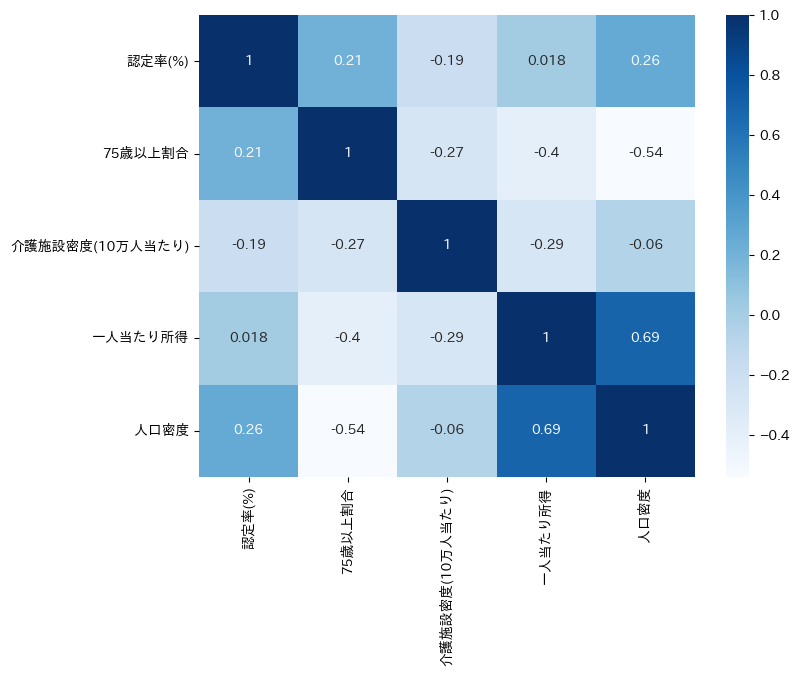

In [ ]:
#ヒートマップ

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.heatmap(
    df_merged.corr(numeric_only=True),
    annot=True,
    cmap="Blues"
)

plt.show()

<Axes: xlabel='75歳以上割合', ylabel='認定率(%)'>

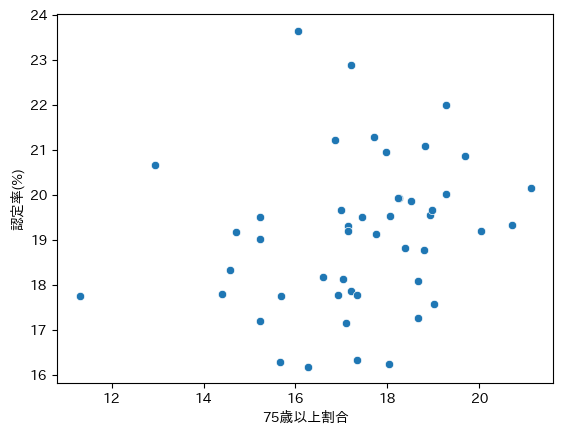

In [ ]:
sns.scatterplot(
    data=df_merged,
    x="75歳以上割合",
    y="認定率(%)"
)

<Axes: xlabel='人口密度', ylabel='認定率(%)'>

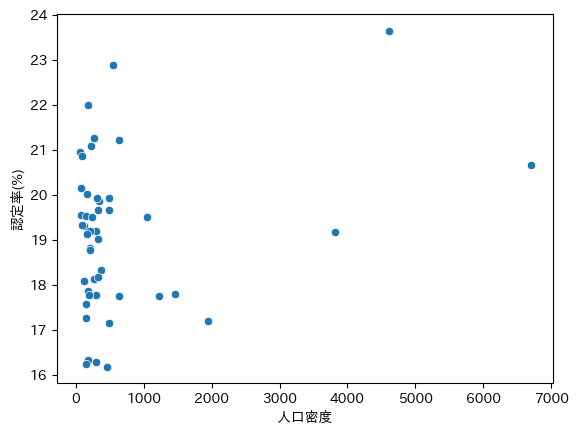

In [ ]:
sns.scatterplot(
    data=df_merged,
    x="人口密度",
    y="認定率(%)"
)

In [ ]:
df_merged.sort_values("人口密度", ascending=False)

,都道府県,認定率(%),75歳以上割合,介護施設密度(10万人当たり),一人当たり所得,人口密度
12,東京都,20.658843,12.941928,427.372463,5757.0,6694.866920
26,大阪府,23.647598,16.056145,326.936745,3055.0,4609.679116
13,神奈川県,19.173998,14.714487,370.618557,3199.0,3819.950331
10,埼玉県,17.202733,15.223026,374.193548,3038.0,1945.594480
22,愛知県,17.790023,14.404173,447.168059,3661.0,1461.493354
11,千葉県,17.749049,15.678440,383.995923,3058.0,1231.208186
39,福岡県,19.509419,15.226337,432.561133,2838.0,1052.816175
46,沖縄県,17.756254,11.307902,866.265060,2396.0,644.707949
27,兵庫県,21.211759,16.852886,296.243094,3038.0,639.590281
25,京都府,22.880715,17.199211,308.944954,3005.0,549.533926


In [ ]:
#重回帰モデル作成

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

#説明変数
X = df_merged[["75歳以上割合", "介護施設密度(10万人当たり)", "一人当たり所得", "人口密度"]]

#目的変数
y = df_merged["認定率(%)"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)

#モデル
model = LinearRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("R2 score", r2_score(y_test, y_pred))

R2 score -0.0028217850804954647


In [ ]:
pd.DataFrame({
    "特徴量": X.columns,
    "係数": model.coef_
})

,特徴量,係数
0,75歳以上割合,0.265050
1,介護施設密度(10万人当たり),-0.003810
2,一人当たり所得,-0.001462
3,人口密度,0.001016


In [ ]:
#ランダムフォレスト

from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print(r2_score(y_test, y_pred_rf))

-0.2887048846242073


##結果

・認定率と75歳以上人口、人口密度ともも弱い正の相関がみられた。
・一方、重回帰モデルのR²は低く、都道府県単位データのみでは認定率を十分説明できなかった
・RandomForestRegressorではさらに精度が低下し、小規模データにおける過学習の可能性がある。

##今後の課題
・市区町村単位データでの分析
・医療資源・単身高齢者割合など追加指標の導入
・時系列データによる分析